# Pandoc-Symreg EqSat Replication, Then a Multiset Hypothesis

This tutorial reproduces a small `pandoc-symreg` equality-saturation pipeline in Egglog and then
asks a narrower follow-up question: if we replace binary associative/commutative structure with
multiset containers, do we reduce A/C blow-up without breaking the rest of the simplification flow?

The source material for provenance is the local clone at `/Users/saul/p/pandoc-symreg`, especially:

- `/Users/saul/p/pandoc-symreg/problems`
- `/Users/saul/p/pandoc-symreg/erro`
- `/Users/saul/p/pandoc-symreg/examples/feynman_I_6_2.hl`
- `/Users/saul/p/pandoc-symreg/examples/example.pysr`
- `/Users/saul/p/pandoc-symreg/src/Data/SRTree/EqSat.hs`

We copy the four main rule families from `EqSat.hs` into Egglog:

- `rewritesBasic`
- `constReduction`
- `constFusion`
- `rewritesFun`

The baseline section below is the replication target. The multiset section is a hypothesis test.

In [1]:
from __future__ import annotations

from collections.abc import Iterable

try:
    import matplotlib.pyplot as plt
except ImportError:  # pragma: no cover - docs environments usually have matplotlib
    plt = None

from egglog.exp.pandoc_symreg import (
    PipelineReport,
    Witness,
    build_sanity_witnesses,
    count_float_params,
    run_binary_pipeline,
    run_multiset_pipeline,
    selected_witnesses,
)

## 1. Overview of the chosen problems

We use three kinds of examples:

- `erro:1` is the sanity case. It is small and it really does reduce parameter count.
- `problems:4` is the readable A/C witness.
- `feynman_I_6_2.hl:11` is the larger dramatic A/C witness.
- `example.pysr:3` is an optional extra stress case.

The paper evaluates simplification mainly by how much it reduces the number of parameters. It also
checks whether the remaining parameters are actually linearly independent by comparing against the
numeric rank of the Jacobian. We use the same post-extraction scoring idea here:

1. Convert non-integer float constants to parameters.
2. Count resulting parameters.
3. Compare that count to numeric Jacobian rank.

We also track engineering metrics that matter for the multiset hypothesis:

- extracted cost
- total e-graph size via `sum(size for _, size in egraph.all_function_sizes())`
- wall-clock runtime
- sampled numeric agreement with the original expression

In [2]:
sanity_1, sanity_2 = build_sanity_witnesses()
readable, dramatic, pysr_stress = selected_witnesses()
core_witnesses = [sanity_1, readable, dramatic]


def _format_table(rows: list[dict[str, str]]) -> str:
    headers = list(rows[0])
    widths = {header: max(len(header), *(len(str(row[header])) for row in rows)) for header in headers}
    header_line = " | ".join(header.ljust(widths[header]) for header in headers)
    separator = "-+-".join("-" * widths[header] for header in headers)
    body = "\n".join(" | ".join(str(row[header]).ljust(widths[header]) for header in headers) for row in rows)
    return f"{header_line}\n{separator}\n{body}"


def _overview_rows(witnesses: Iterable[Witness]) -> list[dict[str, str]]:
    rows: list[dict[str, str]] = []
    for witness in witnesses:
        rows.append({
            "name": witness.name,
            "source": f"{witness.source_path}:{witness.row}",
            "inputs": ", ".join(witness.input_names),
            "float_params_before": str(count_float_params(witness.expr)),
            "description": witness.description,
        })
    return rows


print(_format_table(_overview_rows([sanity_1, readable, dramatic, pysr_stress])))

name        | source                                                   | inputs       | float_params_before | description                                                                        
------------+----------------------------------------------------------+--------------+---------------------+------------------------------------------------------------------------------------
erro-1      | /Users/saul/p/pandoc-symreg/erro:1                       | X2, X3       | 4                   | Small factorization sanity case from erro:1. This one does reduce parameter count. 
readable    | /Users/saul/p/pandoc-symreg/problems:4                   | x1, x2       | 2                   | Small nonlinear example from problems:4 with additive structure inside abs/log/exp.
dramatic    | /Users/saul/p/pandoc-symreg/examples/feynman_I_6_2.hl:11 | theta, sigma | 11                  | A/C-heavy Feynman example with additive linear terms and nonlinear atoms.          
pysr-stress | /Users/saul/p/pa

## 2. Binary EqSat replication in Egglog

The baseline pipeline matches the Haskell schedule shape from `pandoc-symreg`:

- `rewriteConst = rewritesBasic + constReduction`
- `rewriteAll = rewritesBasic + constReduction + constFusion + rewritesFun`
- run the `const` pass once
- run the `all` pass up to two more times, rebuilding from the extracted term between passes

All saturation is driven through `egraph.run(schedule.saturate())`. There are no direct
saturation calls on `EGraph` itself.

We start with the three core witnesses. `erro:1` is included first because it is the cleanest
demonstration that the replicated Egglog rules do perform the kind of parameter reduction the
paper reports.

In [3]:
binary_reports = {witness.name: run_binary_pipeline(witness) for witness in core_witnesses}


def _report_row(witness: Witness, report: PipelineReport) -> dict[str, str]:
    before_params = count_float_params(witness.expr)
    metrics = report.metric_report
    return {
        "witness": witness.name,
        "before_params": str(before_params),
        "after_params": str(metrics.parameter_count),
        "ratio": f"{metrics.parameter_reduction_ratio:.3f}",
        "jacobian_rank": str(metrics.jacobian_rank),
        "rank_gap": str(metrics.parameter_count - metrics.jacobian_rank),
        "cost": str(report.cost),
        "total_size": str(report.total_size),
        "time_sec": f"{report.total_sec:.4f}",
        "max_abs_error": f"{report.numeric_max_abs_error:.3g}",
    }


print(_format_table([_report_row(w, binary_reports[w.name]) for w in core_witnesses]))

witness  | before_params | after_params | ratio | jacobian_rank | rank_gap | cost | total_size | time_sec | max_abs_error
---------+---------------+--------------+-------+---------------+----------+------+------------+----------+--------------
erro-1   | 4             | 2            | 0.500 | 2             | 0        | 19   | 17         | 0.0475   | 0            
readable | 2             | 2            | 0.000 | 2             | 0        | 23   | 49         | 0.0124   | 0            
dramatic | 11            | 11           | 0.000 | 5             | 6        | 107  | 338        | 0.0235   | 0            


`erro:1` is the positive replication case:

- the starting expression has four float parameters
- the Egglog EqSat pipeline reduces that to two
- the parameter-reduction ratio is therefore `0.5`

The two A/C witnesses are different: they are here mainly to stress the representation. Under the
copied rules, they keep the same parameter count after simplification, so they are useful for
measuring graph growth and extraction stability rather than paper-style parameter reduction.

In [4]:
for witness in core_witnesses:
    report = binary_reports[witness.name]
    print(f"{witness.name} extracted:")
    print(report.python_source)
    print()

erro-1 extracted:
(9.453222 + ((X3 + X2) * -1.083105375008))

readable extracted:
(-np.exp(np.log(np.abs(((-1.3 * x1) + (1.56 * x2))))))

dramatic extracted:
(((((theta * ((sigma * -0.175176339) + ((theta * 0.102369047) + -0.464405298))) + (sigma * 0.736577255)) + (np.exp(((sigma * theta) * 2.55279029)) * 2.86662658e-11)) + (959.586017 / ((((sigma * sigma) * np.exp((theta * -0.891744723))) * 83.1663039) + 317.624683))) + -2.69989657)



## 3. Replacing binary A/C with multisets

The multiset hypothesis is narrower than the baseline replication:

- additive islands become `sum_(MultiSet[Term])`
- multiplicative islands become `product_(MultiSet[Term])`
- constants inside those containers are combined there
- one distributive expansion rule is ported to the container world

The important limitation is that this is still a partial integration. After the multiset phase, the
current implementation reruns the copied binary rules on the extracted term so that downstream
simplifications from `constFusion` and `rewritesFun` still fire.

In [5]:
multiset_reports = {
    witness.name: run_multiset_pipeline(witness) for witness in [sanity_1, readable, dramatic, pysr_stress]
}
print(_format_table([_report_row(w, multiset_reports[w.name]) for w in [sanity_1, readable, dramatic, pysr_stress]]))

witness     | before_params | after_params | ratio | jacobian_rank | rank_gap | cost | total_size | time_sec | max_abs_error
------------+---------------+--------------+-------+---------------+----------+------+------------+----------+--------------
erro-1      | 4             | 2            | 0.500 | 2             | 0        | 19   | 14         | 0.0200   | 0            
readable    | 2             | 2            | 0.000 | 2             | 0        | 23   | 18         | 0.0165   | 0            
dramatic    | 11            | 11           | 0.000 | 5             | 6        | 107  | 59         | 0.0719   | 0            
pysr-stress | 10            | 10           | 0.000 | 5             | 5        | 101  | 51         | 0.0290   | 0            


The extracted forms remain numerically identical on the sampled points, but the representation
changes the e-graph size significantly on the A/C-heavy cases.

In [6]:
for witness in [sanity_1, readable, dramatic]:
    report = multiset_reports[witness.name]
    print(f"{witness.name} multiset extracted:")
    print(report.python_source)
    for note in report.notes:
        print(f"note: {note}")
    print()

erro-1 multiset extracted:
(9.453222 + ((X3 + X2) * -1.083105375008))
note: Multiset path currently ports A/C flattening, distributive expansion, and constant combining.
note: Binary pandoc rules are rerun after reifying the multiset result to keep the rest of the EqSat pipeline active.

readable multiset extracted:
(-np.exp(np.log(np.abs(((-1.3 * x1) + (1.56 * x2))))))
note: Multiset path currently ports A/C flattening, distributive expansion, and constant combining.
note: Binary pandoc rules are rerun after reifying the multiset result to keep the rest of the EqSat pipeline active.

dramatic multiset extracted:
(((((theta * ((sigma * -0.175176339) + ((theta * 0.102369047) + -0.464405298))) + (sigma * 0.736577255)) + (np.exp(((theta * sigma) * 2.55279029)) * 2.86662658e-11)) + (959.586017 / ((((sigma * sigma) * np.exp((theta * -0.891744723))) * 83.1663039) + 317.624683))) + -2.69989657)
note: Multiset path currently ports A/C flattening, distributive expansion, and constant combining.

## 4. What improved, what did not, and where the current blocker is

The next table compares the two modes directly on the main witnesses.

In [7]:
comparison_rows: list[dict[str, str]] = []
for witness in [sanity_1, readable, dramatic, pysr_stress]:
    binary = run_binary_pipeline(witness)
    multiset = multiset_reports[witness.name]
    comparison_rows.append({
        "witness": witness.name,
        "binary_size": str(binary.total_size),
        "multiset_size": str(multiset.total_size),
        "size_drop": f"{1 - (multiset.total_size / binary.total_size):.3f}",
        "binary_time": f"{binary.total_sec:.4f}",
        "multiset_time": f"{multiset.total_sec:.4f}",
        "binary_ratio": f"{binary.metric_report.parameter_reduction_ratio:.3f}",
        "multiset_ratio": f"{multiset.metric_report.parameter_reduction_ratio:.3f}",
    })

print(_format_table(comparison_rows))

witness     | binary_size | multiset_size | size_drop | binary_time | multiset_time | binary_ratio | multiset_ratio
------------+-------------+---------------+-----------+-------------+---------------+--------------+---------------
erro-1      | 17          | 14            | 0.176     | 0.0143      | 0.0200        | 0.500        | 0.500         
readable    | 49          | 18            | 0.633     | 0.0123      | 0.0165        | 0.000        | 0.000         
dramatic    | 338         | 59            | 0.825     | 0.0235      | 0.0719        | 0.000        | 0.000         
pysr-stress | 75          | 51            | 0.320     | 0.0140      | 0.0290        | 0.000        | 0.000         


A few conclusions are immediate from the current runs:

- `erro:1` shows that the baseline replication is doing real symbolic work, not just preserving the
  input.
- On the readable and dramatic A/C witnesses, the multiset representation sharply reduces total
  e-graph size while preserving extracted cost and sampled numeric behavior.
- That size reduction does not automatically produce a runtime win yet. The dramatic witness still
  runs slower in the current multiset pipeline because the implementation has to cross from
  containers back into the copied binary rules.

So the current result is mixed:

- hypothesis supported for graph-size control
- not yet supported for faster end-to-end execution
- no parameter-reduction improvement yet on the chosen A/C stress cases

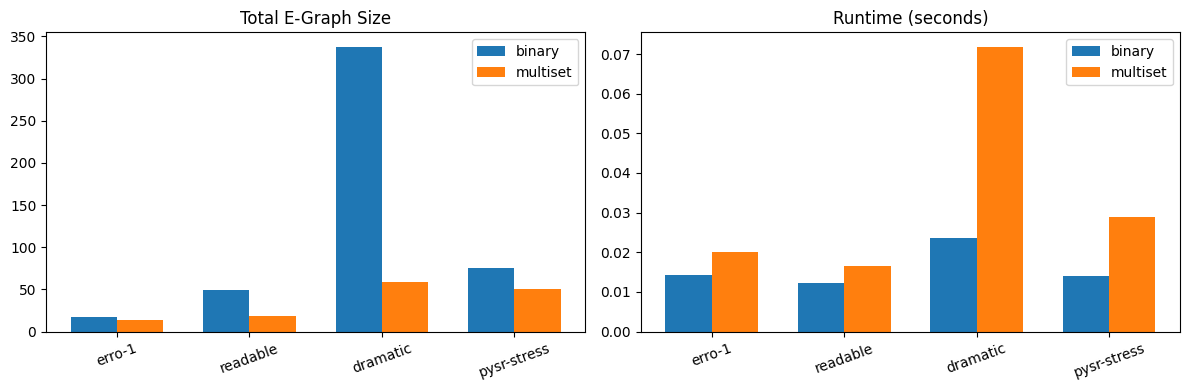

In [8]:
if plt is None:
    print("matplotlib is not installed; skipping plots.")
else:
    names = [row["witness"] for row in comparison_rows]
    binary_sizes = [int(row["binary_size"]) for row in comparison_rows]
    multiset_sizes = [int(row["multiset_size"]) for row in comparison_rows]
    binary_times = [float(row["binary_time"]) for row in comparison_rows]
    multiset_times = [float(row["multiset_time"]) for row in comparison_rows]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = range(len(names))
    width = 0.35

    axes[0].bar([i - width / 2 for i in x], binary_sizes, width=width, label="binary")
    axes[0].bar([i + width / 2 for i in x], multiset_sizes, width=width, label="multiset")
    axes[0].set_title("Total E-Graph Size")
    axes[0].set_xticks(list(x), names, rotation=20)
    axes[0].legend()

    axes[1].bar([i - width / 2 for i in x], binary_times, width=width, label="binary")
    axes[1].bar([i + width / 2 for i in x], multiset_times, width=width, label="multiset")
    axes[1].set_title("Runtime (seconds)")
    axes[1].set_xticks(list(x), names, rotation=20)
    axes[1].legend()

    plt.tight_layout()
    fig

The current blocker is not correctness but integration depth. The multiset phase still has to hand
control back to the binary rule set to recover the rest of the EqSat behavior. A more complete
container-native port of `constFusion` and the nonlinear rules would be the next step if the goal is
to turn the graph-size win into a runtime win as well.